# VAE Sanity Check

Simple verification that input → encoder → decoder → output flows correctly.
- Load a real dSprites example
- Pass through VAE
- Compare input, reconstruction, and latent space


# Setup

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import torch

from src.datasets.dsprites import FACTOR_NAMES, FACTOR_SIZES, load_dsprites
from src.utils.vae_inspection import (
    load_encoder_decoder,
    run_vae_pass,
    prepare_model_input,
    tensor_to_display_image,
)

dataset = load_dsprites('../data')
print(f"Loaded {len(dataset['imgs']):,} dSprites examples")

Loaded 737,280 dSprites examples


In [2]:
ENCODER_CHECKPOINT = None
DECODER_CHECKPOINT = None
LATENT_DIM = 10
IMG_CHANNELS = 1
DEVICE = 'cpu'

encoder, decoder = load_encoder_decoder(
    latent_dim=LATENT_DIM,
    img_channels=IMG_CHANNELS,
    encoder_checkpoint=ENCODER_CHECKPOINT,
    decoder_checkpoint=DECODER_CHECKPOINT,
    device=DEVICE,
)

mode = 'trained' if ENCODER_CHECKPOINT or DECODER_CHECKPOINT else 'random'
print(f'Encoder/decoder loaded ({mode}). latent_dim={encoder.latent_dim}')

Encoder/decoder loaded (random). latent_dim=10


In [3]:
# Select a sample by index or by factor values
SAMPLE_INDEX = 0  # Change this to test different samples
# OR use factor values instead:
# FACTOR_VALUES = {'color': 0, 'shape': 1, 'scale': 2, 'orientation': 0, 'posX': 15, 'posY': 20}

result = run_vae_pass(
    dataset,
    encoder,
    decoder,
    sample_index=SAMPLE_INDEX,
    use_mean_latent=True,  # Set to False to sample from distribution
)

print(f"Sample index: {result.sample_index}")
print(f"Factors: {result.factors}")
print(f"Reconstruction MSE: {result.mse:.6f}")
print(f"Latent mu: {result.mu}")
print(f"Latent logvar: {result.logvar}")

Sample index: 0
Factors: {'color': 0, 'shape': 0, 'scale': 0, 'orientation': 0, 'pos_x': 0, 'pos_y': 0}
Reconstruction MSE: 0.311839
Latent mu: [ 0.00662709  0.03879092 -0.03477303 -0.01283948 -0.05099503  0.05903764
  0.02270946 -0.01250269  0.03756327  0.02256965]
Latent logvar: [-0.07587828 -0.02743996  0.05679024 -0.06454664 -0.00191413  0.02450429
  0.03781575 -0.00930771 -0.00614486  0.05730676]


In [4]:
# Batch processing: input -> encoder -> decoder with shape inspection
BATCH_SIZE = 8
batch_indices = np.random.randint(0, len(dataset['imgs']), BATCH_SIZE)

# Load images
batch_images = dataset['imgs'][batch_indices].astype(np.float32)
print(f"Input batch shape: {batch_images.shape}")

# Prepare for model
x = torch.from_numpy(batch_images).unsqueeze(1).to(DEVICE)  # (B, 1, 64, 64)
print(f"Tensor after unsqueeze: {x.shape}")

# Encode
mu, logvar = encoder.encode(x)
print(f"Encoder output - mu: {mu.shape}, logvar: {logvar.shape}")

# Sample from latent
z = encoder.reparameterize(mu, logvar)
print(f"Latent sample z: {z.shape}")

# Decode
reconstruction = decoder(z)
print(f"Decoder output: {reconstruction.shape}")

# Convert to numpy for display
reconstruction_np = tensor_to_display_image(reconstruction)
print(f"Final reconstruction (numpy): {reconstruction_np.shape}")

print("\n" + "="*60)
print("Shape flow summary:")
print("="*60)
print(f"Input images:       {batch_images.shape}")
print(f"  ↓ unsqueeze(1)")
print(f"Tensor x:           {x.shape}")
print(f"  ↓ encoder.encode()")
print(f"μ (means):          {mu.shape}")
print(f"logvar:             {logvar.shape}")
print(f"  ↓ reparameterize()")
print(f"z (latent):         {z.shape}")
print(f"  ↓ decoder()")
print(f"Reconstruction:     {reconstruction.shape}")
print(f"  ↓ to_display_image()")
print(f"Display shape:      {reconstruction_np.shape}")

Input batch shape: (8, 64, 64)
Tensor after unsqueeze: torch.Size([8, 1, 64, 64])
Encoder output - mu: torch.Size([8, 10]), logvar: torch.Size([8, 10])
Latent sample z: torch.Size([8, 10])
Decoder output: torch.Size([8, 1, 64, 64])
Final reconstruction (numpy): (64, 64)

Shape flow summary:
Input images:       (8, 64, 64)
  ↓ unsqueeze(1)
Tensor x:           torch.Size([8, 1, 64, 64])
  ↓ encoder.encode()
μ (means):          torch.Size([8, 10])
logvar:             torch.Size([8, 10])
  ↓ reparameterize()
z (latent):         torch.Size([8, 10])
  ↓ decoder()
Reconstruction:     torch.Size([8, 1, 64, 64])
  ↓ to_display_image()
Display shape:      (64, 64)


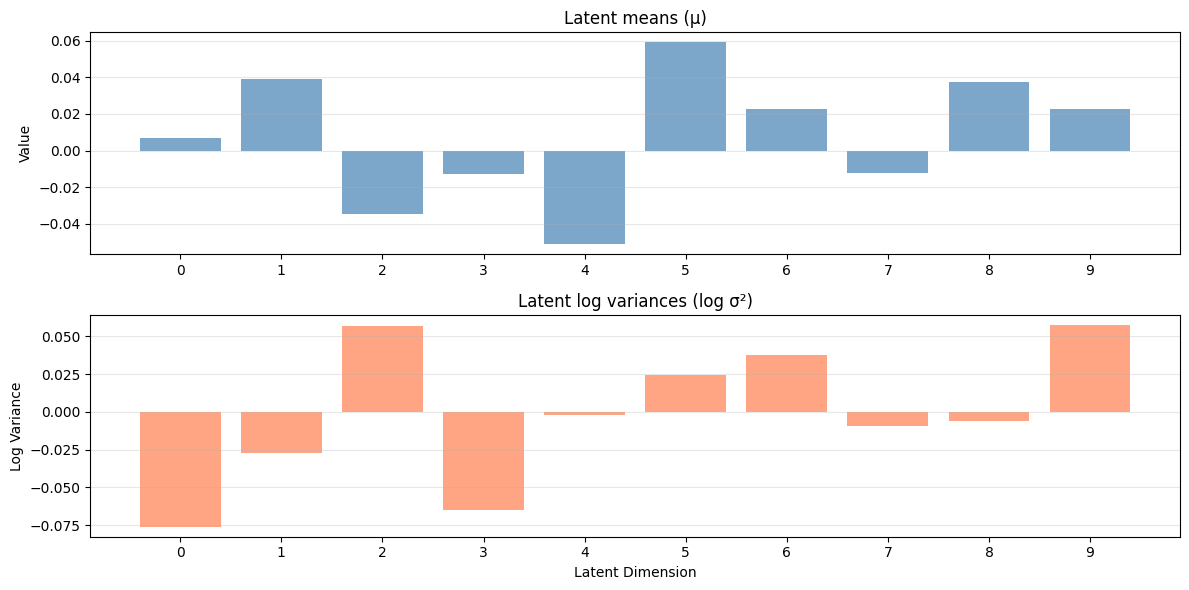

In [5]:
# Latent space visualization
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Means
x = np.arange(encoder.latent_dim)
axes[0].bar(x, result.mu, color='steelblue', alpha=0.7)
axes[0].set_ylabel('Value')
axes[0].set_title('Latent means (μ)')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticks(x)

# Log variances (log-scale for interpretability)
axes[1].bar(x, result.logvar, color='coral', alpha=0.7)
axes[1].set_ylabel('Log Variance')
axes[1].set_xlabel('Latent Dimension')
axes[1].set_title('Latent log variances (log σ²)')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticks(x)

plt.tight_layout()
plt.show()

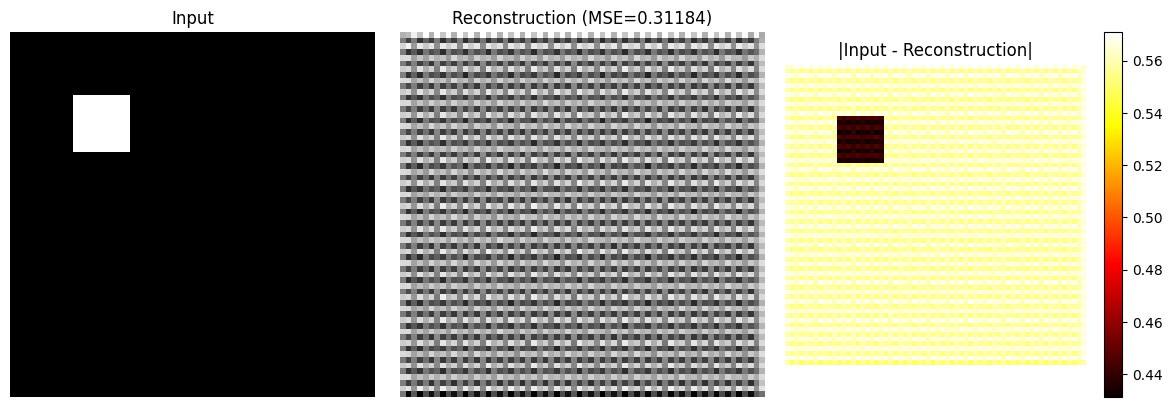

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(result.input_image, cmap='gray')
axes[0].set_title('Input')
axes[0].axis('off')

axes[1].imshow(result.reconstruction, cmap='gray')
axes[1].set_title(f'Reconstruction (MSE={result.mse:.5f})')
axes[1].axis('off')

residual = np.abs(result.input_image - result.reconstruction)
im = axes[2].imshow(residual, cmap='hot')
axes[2].set_title('|Input - Reconstruction|')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.show()